In [5]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)  # show all columns when printing

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Try converting to numeric and see what fails
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [12]:
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [13]:
# Look at the rows where TotalCharges fails to convert
broken_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()
df[broken_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Confirm how many nulls we now have
df['TotalCharges'].isnull().sum()

np.int64(11)

In [15]:
df.loc[df['tenure'] == 0, 'TotalCharges'] = df.loc[df['tenure'] == 0, 'TotalCharges'].fillna(0)

# Verify no more missing values
df['TotalCharges'].isnull().sum()

np.int64(0)

In [16]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')  # not a real category

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
    print()

gender: ['Female' 'Male']

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn: ['No' 'Yes']



In [17]:
df = df.drop('customerID', axis=1)
df.shape

(7043, 20)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

/tmp/ipykernel_750/2279214412.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['#2ecc71', '#e74c3c'])


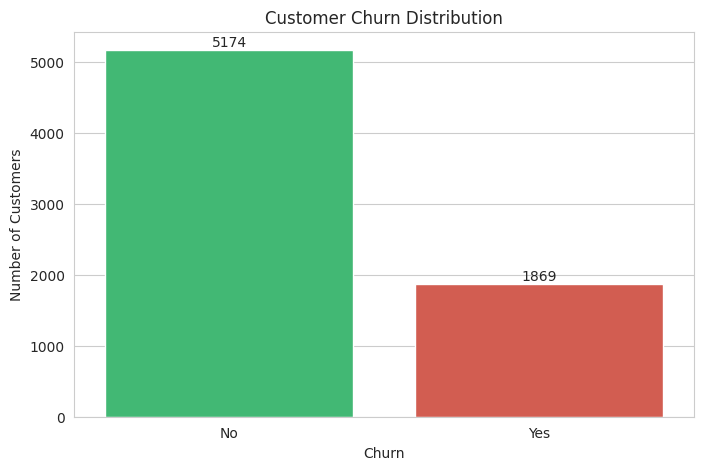

Churn rate: 26.54%


In [19]:
churn_counts = df['Churn'].value_counts()

plt.figure()
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

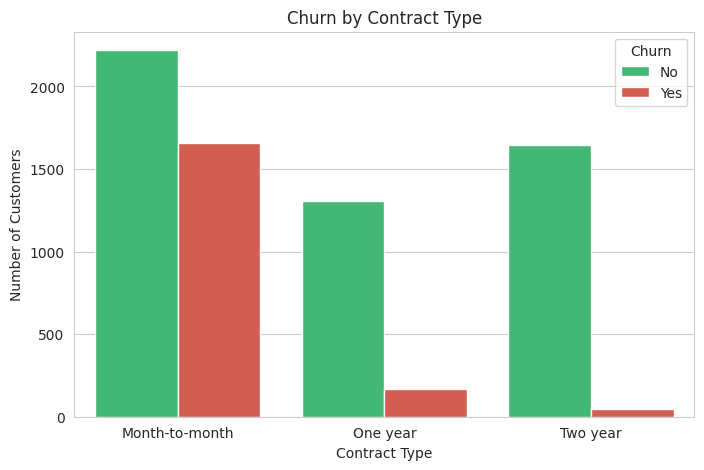

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [20]:
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

# Churn rate by contract, as a percentage
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(contract_churn)

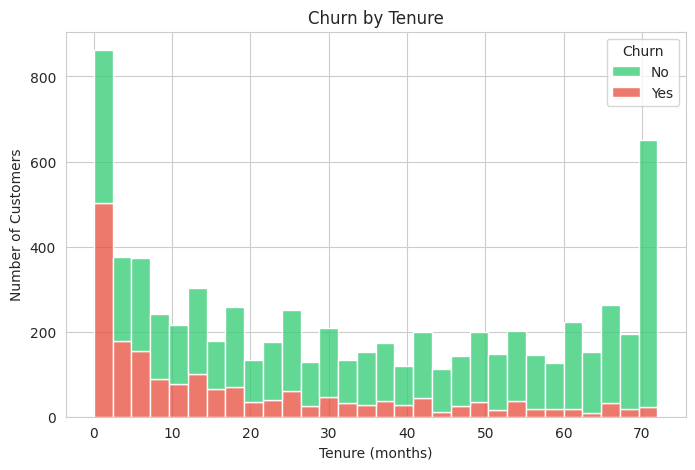

In [21]:
plt.figure()
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipykernel_750/1045265785.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])


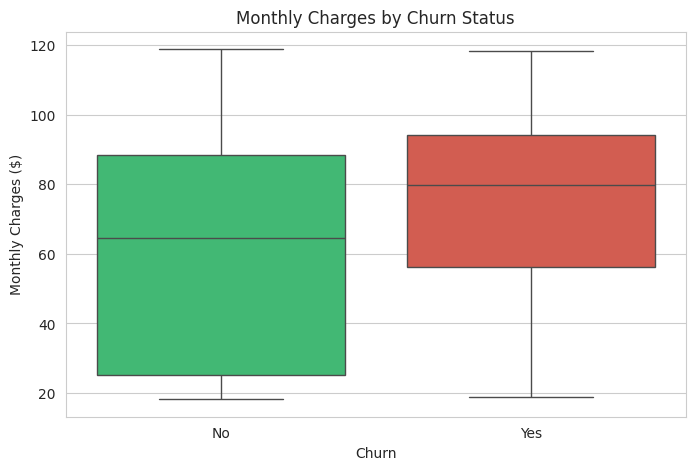

In [22]:
plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

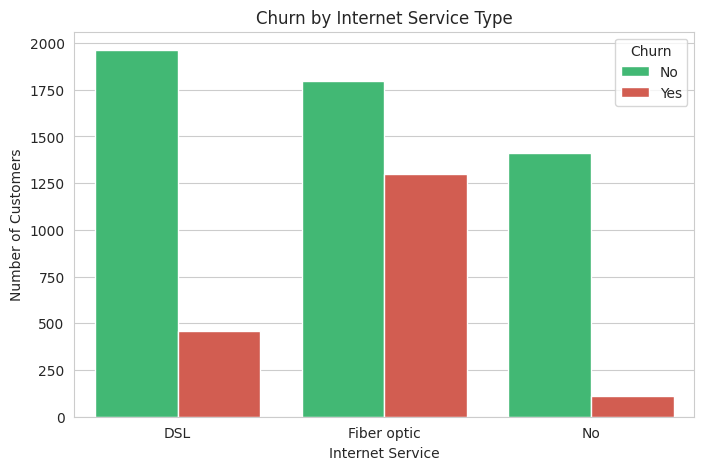

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64


In [23]:
plt.figure()
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(internet_churn)

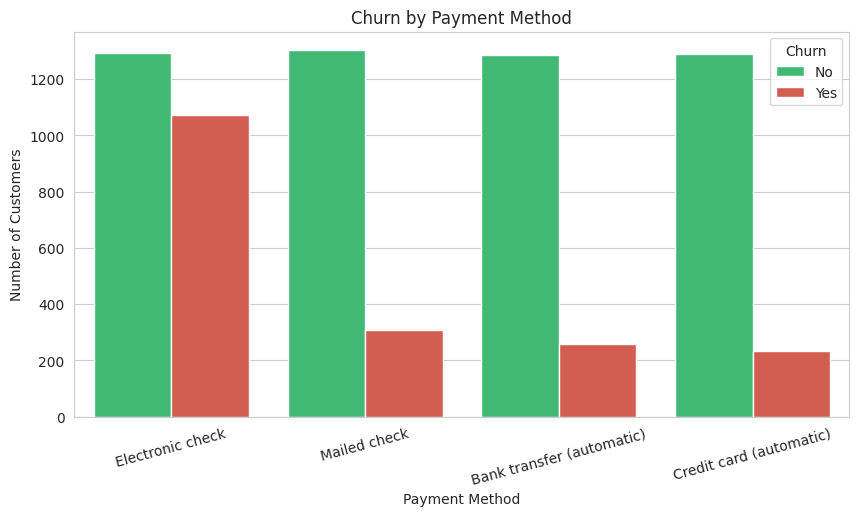

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64


In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(payment_churn)

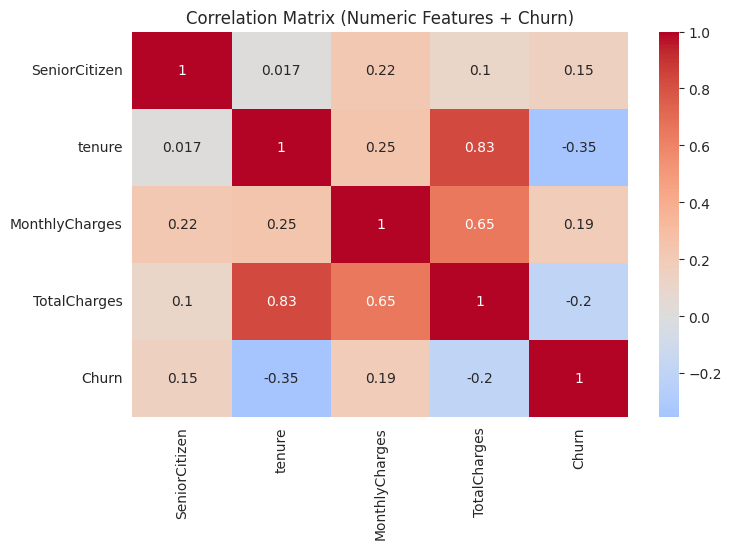

In [25]:
numeric_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric Features + Churn)')
plt.show()

In [26]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 year'
    elif tenure <= 24:
        return '1-2 years'
    elif tenure <= 48:
        return '2-4 years'
    else:
        return '4+ years'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
df['TenureGroup'].value_counts()

,count
TenureGroup,
4+ years,2239
0-1 year,2186
2-4 years,1594
1-2 years,1024


In [27]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = (df[service_cols] == 'Yes').sum(axis=1)
df['NumServices'].value_counts().sort_index()

,count
NumServices,
0,2219
1,966
2,1033
3,1118
4,852
5,571
6,284


In [28]:
df['HasInternetAndPhone'] = ((df['InternetService'] != 'No') & (df['PhoneService'] == 'Yes')).astype(int)
df['HasInternetAndPhone'].value_counts()

,count
HasInternetAndPhone,
1,4835
0,2208


In [29]:
# Avoid division by zero for tenure=0 customers
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [30]:
cols_to_simplify = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_simplify:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Verify
for col in cols_to_simplify:
    print(f"{col}: {df[col].unique()}")

MultipleLines: ['No' 'Yes']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']


In [31]:
df.shape
df.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureGroup',
 'NumServices',
 'HasInternetAndPhone',
 'AvgMonthlySpend']

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = (df['Churn'] == 'Yes').astype(int)  # convert target to 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (5634, 23)
Test shape: (1409, 23)

Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


In [33]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumServices']

categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                         'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                         'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup',
                         'HasInternetAndPhone']

print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))
print("Total:", len(numerical_features) + len(categorical_features))

Numerical: 5
Categorical: 18
Total: 23


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges',
                                  'AvgMonthlySpend', 'NumServices']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'TenureGroup', 'HasInternetAndPhone'])])

In [35]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (5634, 29)
Processed test shape: (1409, 29)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

In [37]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_processed, y_train)

y_pred_lr = log_reg.predict(X_test_processed)
y_proba_lr = log_reg.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [38]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)
y_proba_rf = rf.predict_proba(X_test_processed)[:, 1]

print("Random Forest trained.")

Random Forest trained.


In [39]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_processed, y_train)

y_pred_xgb = xgb.predict(X_test_processed)
y_proba_xgb = xgb.predict_proba(X_test_processed)[:, 1]

print("XGBoost trained.")

XGBoost trained.


In [40]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = [
    evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr),
    evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf),
    evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb)
]

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.799148,0.653199,0.518717,0.578241,0.842652
1,Random Forest,0.792051,0.635452,0.508021,0.564636,0.824830
2,XGBoost,0.776437,0.593651,0.500000,0.542816,0.815920


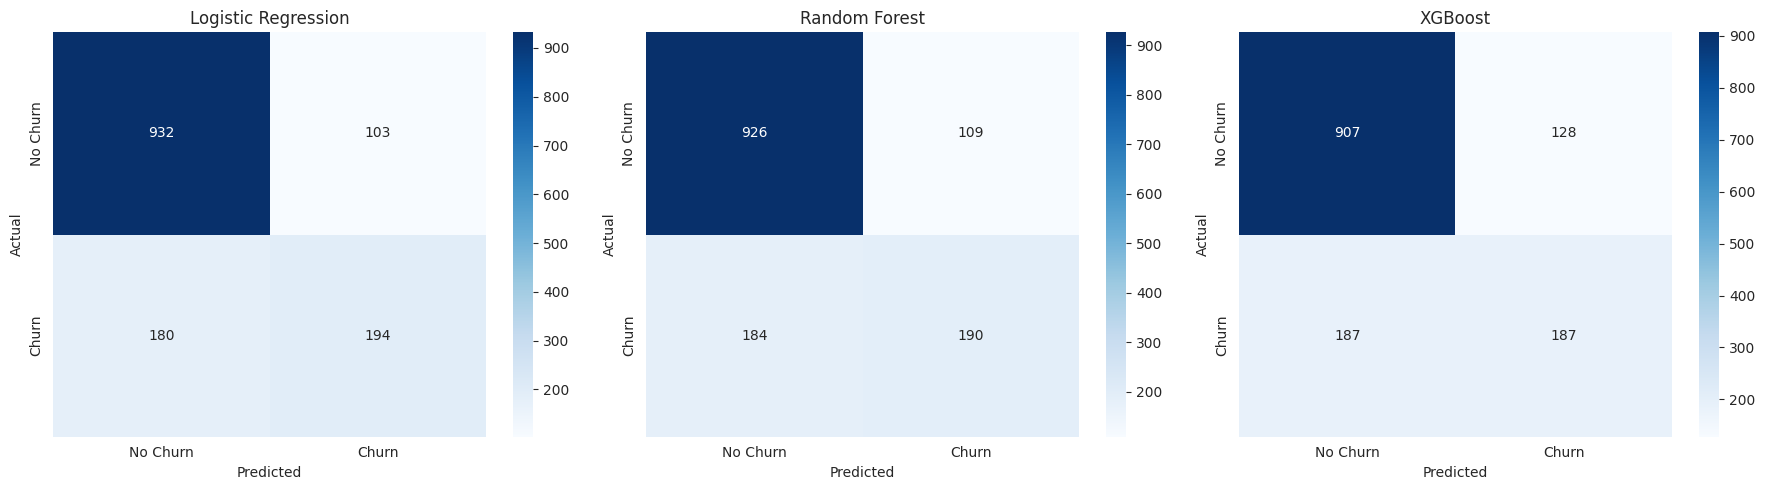

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                       ('Random Forest', y_pred_rf),
                                       ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression with class_weight='balanced'
log_reg_bal = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg_bal.fit(X_train_processed, y_train)
y_pred_lr_bal = log_reg_bal.predict(X_test_processed)
y_proba_lr_bal = log_reg_bal.predict_proba(X_test_processed)[:, 1]

# Random Forest with class_weight='balanced'
rf_bal = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_bal.fit(X_train_processed, y_train)
y_pred_rf_bal = rf_bal.predict(X_test_processed)
y_proba_rf_bal = rf_bal.predict_proba(X_test_processed)[:, 1]

# XGBoost uses scale_pos_weight instead of class_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_bal = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_bal.fit(X_train_processed, y_train)
y_pred_xgb_bal = xgb_bal.predict(X_test_processed)
y_proba_xgb_bal = xgb_bal.predict_proba(X_test_processed)[:, 1]

print("All balanced models trained.")

scale_pos_weight: 2.768561872909699
All balanced models trained.


In [43]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Original train shape:", X_train_processed.shape, "Churn rate:", y_train.mean())
print("SMOTE train shape:", X_train_smote.shape, "Churn rate:", y_train_smote.mean())

# Train Logistic Regression on SMOTE data (as an example comparison)
log_reg_smote = LogisticRegression(random_state=42, max_iter=1000)
log_reg_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = log_reg_smote.predict(X_test_processed)
y_proba_lr_smote = log_reg_smote.predict_proba(X_test_processed)[:, 1]

print("SMOTE model trained.")

Original train shape: (5634, 29) Churn rate: 0.2653532126375577
SMOTE train shape: (8278, 29) Churn rate: 0.5
SMOTE model trained.


In [44]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

imbalance_results = [
    evaluate_model('LogReg (original)', y_test, y_pred_lr, y_proba_lr),
    evaluate_model('LogReg (class_weight)', y_test, y_pred_lr_bal, y_proba_lr_bal),
    evaluate_model('LogReg (SMOTE)', y_test, y_pred_lr_smote, y_proba_lr_smote),
    evaluate_model('RF (original)', y_test, y_pred_rf, y_proba_rf),
    evaluate_model('RF (class_weight)', y_test, y_pred_rf_bal, y_proba_rf_bal),
    evaluate_model('XGBoost (original)', y_test, y_pred_xgb, y_proba_xgb),
    evaluate_model('XGBoost (scale_pos_weight)', y_test, y_pred_xgb_bal, y_proba_xgb_bal),
]

imbalance_df = pd.DataFrame(imbalance_results).sort_values('F1-Score', ascending=False)
imbalance_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,LogReg (SMOTE),0.739532,0.505963,0.794118,0.618106,0.839823
1,LogReg (class_weight),0.733144,0.498311,0.788770,0.610766,0.842187
6,XGBoost (scale_pos_weight),0.762243,0.543046,0.657754,0.594921,0.823537
0,LogReg (original),0.799148,0.653199,0.518717,0.578241,0.842652
3,RF (original),0.792051,0.635452,0.508021,0.564636,0.824830
5,XGBoost (original),0.776437,0.593651,0.500000,0.542816,0.815920
4,RF (class_weight),0.784954,0.625442,0.473262,0.538813,0.822543


In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid_lr,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train_processed, y_train)

print("Best params:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.6321331063837569


In [46]:
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_processed)
y_proba_lr_tuned = best_lr.predict_proba(X_test_processed)[:, 1]

print("Tuned LogReg test performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"F1: {f1_score(y_test, y_pred_lr_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr_tuned):.4f}")

Tuned LogReg test performance:
Accuracy: 0.7402
Precision: 0.5070
Recall: 0.7701
F1: 0.6115
ROC-AUC: 0.8389


In [47]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train_processed, y_train)

print("Best params:", random_xgb.best_params_)
print("Best CV F1:", random_xgb.best_score_)

Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV F1: 0.6345098556555564


In [48]:
best_xgb = random_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_processed)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test_processed)[:, 1]

print("Tuned XGBoost test performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"F1: {f1_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb_tuned):.4f}")

Tuned XGBoost test performance:
Accuracy: 0.7559
Precision: 0.5261
Recall: 0.8075
F1: 0.6371
ROC-AUC: 0.8467


In [49]:
tuning_comparison = pd.DataFrame([
    evaluate_model('LogReg (class_weight, untuned)', y_test, y_pred_lr_bal, y_proba_lr_bal),
    evaluate_model('LogReg (tuned)', y_test, y_pred_lr_tuned, y_proba_lr_tuned),
    evaluate_model('XGBoost (scale_pos_weight, untuned)', y_test, y_pred_xgb_bal, y_proba_xgb_bal),
    evaluate_model('XGBoost (tuned)', y_test, y_pred_xgb_tuned, y_proba_xgb_tuned),
]).sort_values('F1-Score', ascending=False)

tuning_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,XGBoost (tuned),0.755855,0.526132,0.807487,0.637131,0.846680
1,LogReg (tuned),0.740241,0.507042,0.770053,0.611465,0.838929
0,"LogReg (class_weight, untuned)",0.733144,0.498311,0.788770,0.610766,0.842187
2,"XGBoost (scale_pos_weight, untuned)",0.762243,0.543046,0.657754,0.594921,0.823537


In [50]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_processed)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 29)


In [51]:
# Extract feature names from the fitted preprocessor
num_feature_names = numerical_features
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

all_feature_names = num_feature_names + cat_feature_names
print("Total features:", len(all_feature_names))
print(all_feature_names)

Total features: 29
['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumServices', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureGroup_1-2 years', 'TenureGroup_2-4 years', 'TenureGroup_4+ years', 'HasInternetAndPhone_1']


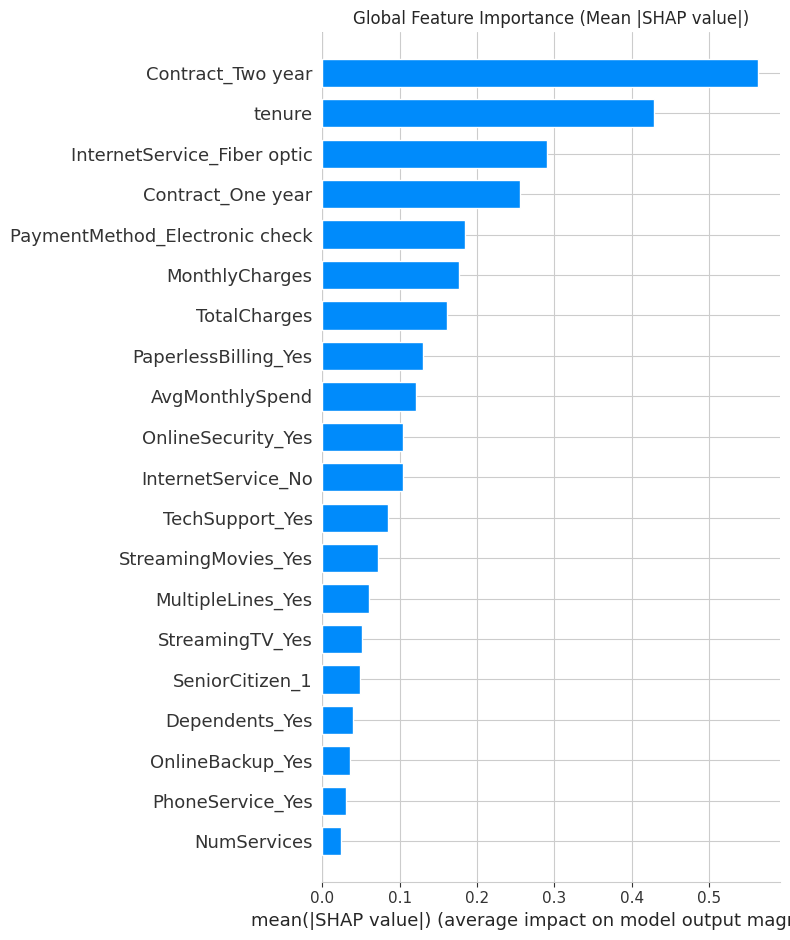

In [52]:
# Convert sparse matrix to dense if needed for SHAP plotting
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed

shap.summary_plot(shap_values, X_test_dense, feature_names=all_feature_names, plot_type='bar', show=False)
plt.title('Global Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.show()

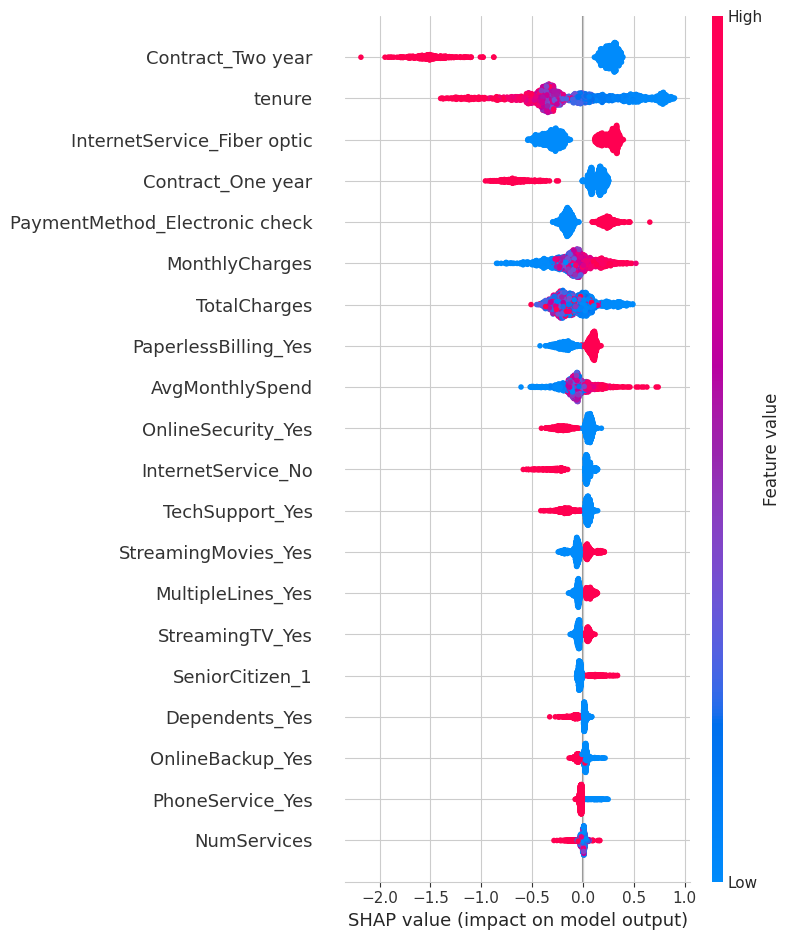

In [53]:
shap.summary_plot(shap_values, X_test_dense, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

In [54]:
# Pick a customer who actually churned, for a meaningful example
churned_customers = np.where(y_test.values == 1)[0]
sample_idx = churned_customers[0]

print("Customer index:", sample_idx)
print("Actual outcome:", "Churned" if y_test.iloc[sample_idx] == 1 else "Did not churn")
print("Predicted probability of churn:", best_xgb.predict_proba(X_test_processed[sample_idx].reshape(1, -1))[0][1])

# Show original (pre-processed) customer details for context
X_test.iloc[sample_idx]

Customer index: 9
Actual outcome: Churned
Predicted probability of churn: 0.6335738


,1639
gender,Male
SeniorCitizen,1
Partner,No
Dependents,No
tenure,17
PhoneService,Yes
MultipleLines,No
InternetService,DSL
OnlineSecurity,No
OnlineBackup,No


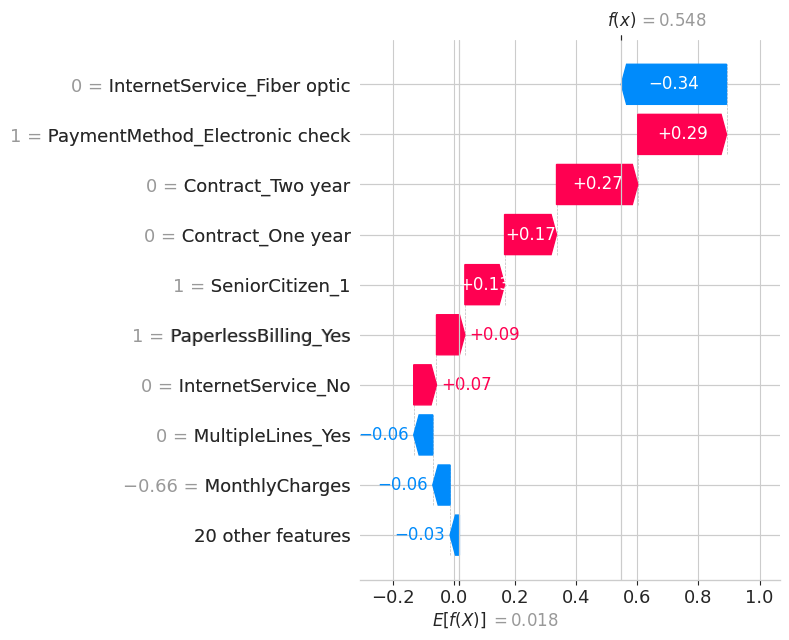

In [55]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_dense[sample_idx],
        feature_names=all_feature_names
    ),
    show=False
)
plt.tight_layout()
plt.show()

In [56]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_xgb)
])

# Sanity check: refit on the ORIGINAL (unprocessed) training data end-to-end
# This confirms the full pipeline works from raw input to prediction
final_pipeline.fit(X_train, y_train)

print("Pipeline fitted successfully.")

Pipeline fitted successfully.


In [57]:
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

print("Combined pipeline test performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"F1: {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

Combined pipeline test performance:
Accuracy: 0.7559
Precision: 0.5261
Recall: 0.8075
F1: 0.6371
ROC-AUC: 0.8467


In [58]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(final_pipeline, 'models/churn_model.joblib')

print("Model saved to models/churn_model.joblib")
print("File size:", os.path.getsize('models/churn_model.joblib') / 1024, "KB")

Model saved to models/churn_model.joblib
File size: 254.1875 KB


In [59]:
loaded_pipeline = joblib.load('models/churn_model.joblib')

# Test on a single raw customer row
test_customer = X_test.iloc[[0]]  # double brackets keep it as a DataFrame
prediction = loaded_pipeline.predict(test_customer)
probability = loaded_pipeline.predict_proba(test_customer)[:, 1]

print("Prediction:", "Churn" if prediction[0] == 1 else "No Churn")
print("Probability:", probability[0])

Prediction: No Churn
Probability: 0.03426177


In [ ]:
from google.colab import files
files.download('models/churn_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import sklearn
print(sklearn.__version__)

1.6.1


In [2]:
import sklearn, xgboost
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

sklearn: 1.6.1
xgboost: 3.4.1


In [3]:
import xgboost
print(xgboost.__version__)

3.4.1


In [60]:
import os
print(os.path.getsize('models/churn_model.joblib') / 1024, "KB")

254.1875 KB


In [62]:
from google.colab import drive
drive.mount('/content/drive')

import joblib, os
os.makedirs('/content/drive/MyDrive/churn_model_output', exist_ok=True)
joblib.dump(final_pipeline, '/content/drive/MyDrive/churn_model_output/churn_model.joblib')

print("Saved to Drive.")
print("Size:", os.path.getsize('/content/drive/MyDrive/churn_model_output/churn_model.joblib') / 1024, "KB")

Mounted at /content/drive
Saved to Drive.
Size: 254.1875 KB


In [63]:
import os
print(os.path.getsize('models/churn_model.joblib') / 1024, "KB")

254.1875 KB


In [64]:
import joblib

# Try loading right back, in the same environment that saved it
test_load = joblib.load('/content/drive/MyDrive/churn_model_output/churn_model.joblib')
print("Loaded successfully in Colab.")

pred = test_load.predict(X_test.iloc[[0]])
print("Prediction:", pred)

Loaded successfully in Colab.
Prediction: [0]


In [65]:
import joblib
import os

os.makedirs('/content/drive/MyDrive/churn_model_output', exist_ok=True)

# Save the preprocessor with joblib (this part is safe — it's pure sklearn, no XGBoost internals)
joblib.dump(preprocessor, '/content/drive/MyDrive/churn_model_output/preprocessor.joblib')

# Save XGBoost using its OWN native format — avoids the pickle portability issue entirely
best_xgb.save_model('/content/drive/MyDrive/churn_model_output/xgb_model.json')

print("Preprocessor and model saved separately.")

Preprocessor and model saved separately.


In [66]:
import joblib
import os

os.makedirs('/content/drive/MyDrive/churn_model_output', exist_ok=True)

joblib.dump(preprocessor, '/content/drive/MyDrive/churn_model_output/preprocessor.joblib')
best_xgb.save_model('/content/drive/MyDrive/churn_model_output/xgb_model.json')

print("Saved both files.")
print(os.listdir('/content/drive/MyDrive/churn_model_output'))

Saved both files.
['churn_model.joblib', 'preprocessor.joblib', 'xgb_model.json']
